### Méthodes d’insertion

#### 1 Insertion ligne par ligne avec sauvegarde à chaque fois
C’est la méthode la plus simple : on ajoute une ligne, puis on sauvegarde immédiatement.

#### 2 Insertion ligne par ligne avec une seule sauvegarde à la fin
On ajoute les lignes une par une, mais on sauvegarde une seule fois à la fin.

#### 3 executemany()
Permet d’envoyer plusieurs lignes avec une seule commande Python

#### 4 execute_batch()
Les données sont envoyées en petits groupes (paquets)

#### 5 execute_values()
Envoie plusieurs lignes dans une seule grande requête SQL.

#### 6 COPY
Méthode optimisée de PostgreSQL pour importer de gros volumes de données.

#### 7 pandas.to_sql() par défaut
Méthode simple avec Pandas pour envoyer directement un tableau vers PostgreSQL.

#### 8 pandas.to_sql(method='multi', chunksize=...)
Pandas envoie les données par groupes au lieu de ligne par ligne.

#### 9 pandas.to_sql(method=callable) avec COPY
Combine la simplicité de Pandas avec la rapidité de COPY.

#### 10 COPY via un itérateur
Les données sont envoyées progressivement, sans tout charger en mémoire.

## Analyse des performances des méthodes d’insertion 
Le déroulement, étape par étape

![Schéma du workflow du projet](Diagramme.png)

Faker_data.py génère des données factices et produit des fichiers CSV de tailles différentes, de 100 à 1 000 000 de lignes.
À partir de là, deux traitements en parallèle :

Branche de gauche : le fichier 1000000.csv est utilisé séparément par page_size.py, pour étudier l'effet de la taille des paquets, et produire son propre graphique dédié.
Branche de droite : tous les fichiers CSV passent par script run_test.py, qui utilise les 10 méthodes définies dans script.py, et produit deux résultats à la suite : resultat_analyse.csv, puis graphique des temps.

In [1]:
import pandas as pd

g = pd.read_csv("resultats_finaux.csv")

noms = {
    "method1":  "1. for + execute + commit/ligne",
    "method2":  "2. for + execute + commit unique",
    "method3":  "3. executemany",
    "method4":  "4. execute_batch",
    "method5":  "5. execute_values",
    "method6":  "6. COPY (fichier CSV)",
    "method7":  "7. pandas to_sql (défaut)",
    "method8":  "8. pandas to_sql (multi)",
    "method9":  "9. pandas to_sql (COPY callable)",
    "method10": "10. COPY (itérateur)",
}

g["method"] = g["method"].map(noms)

for taille in sorted(g["value"].unique()):
    df = g[g["value"] == taille][["value", "method", "mediane(s)"]].sort_values("mediane(s)")
    df=df.rename(columns={"mediane(s)": "Temps"})
    print(f"{taille:,} lignes")
    print(df.to_markdown(tablefmt="grid", index=False))
    print()





100 lignes
+---------+----------------------------------+------------+
|   value | method                           |      Temps |
+=========+==================================+============+
|     100 | 6. COPY (fichier CSV)            | 0.00335785 |
+---------+----------------------------------+------------+
|     100 | 10. COPY (itérateur)             | 0.00481355 |
+---------+----------------------------------+------------+
|     100 | 5. execute_values                | 0.00740345 |
+---------+----------------------------------+------------+
|     100 | 4. execute_batch                 | 0.0152991  |
+---------+----------------------------------+------------+
|     100 | 3. executemany                   | 0.0971897  |
+---------+----------------------------------+------------+
|     100 | 2. for + execute + commit unique | 0.101051   |
+---------+----------------------------------+------------+
|     100 | 1. for + execute + commit/ligne  | 0.102836   |
+---------+------------------

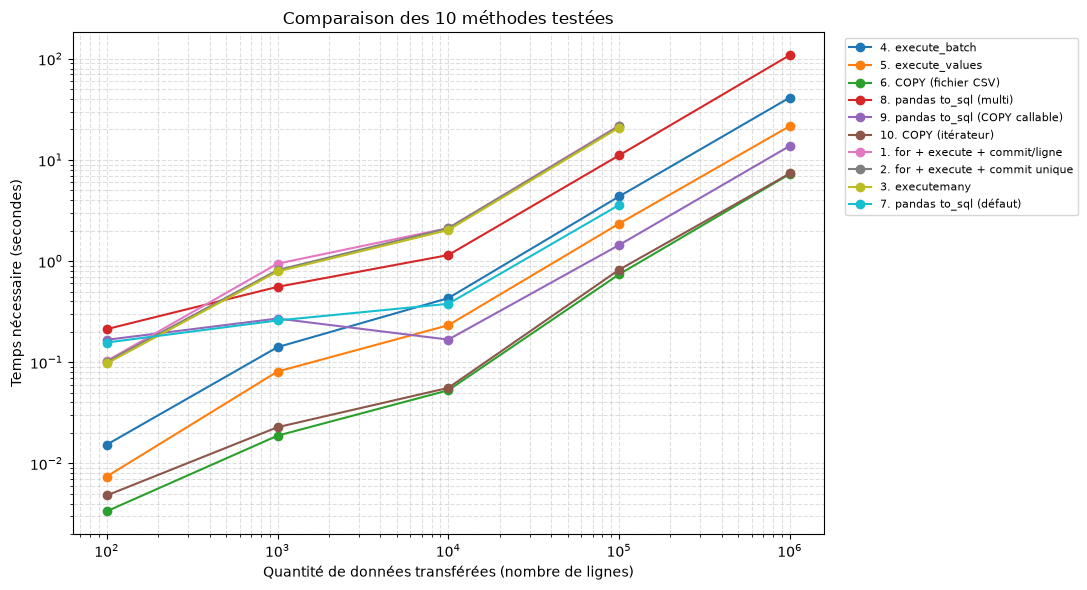

In [2]:
import pandas as pd
import matplotlib.pyplot as plt



plt.figure(figsize=(11, 6))
for m in g["method"].unique():
    sub = g[g["method"] == m].sort_values("value")
    plt.plot(sub["value"], sub["mediane(s)"], marker="o", label=noms.get(m, m))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Quantité de données transférées (nombre de lignes)")
plt.ylabel("Temps nécessaire (secondes)")
plt.title("Comparaison des 10 méthodes testées")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Sur l'ensemble des volumes testés, deux méthodes se voient clairement par leur lenteur : la méthode1 "ligne par ligne" (en rose) et la méthode2 "pandas, mode groupé" (en rouge), cette dernière étant même la plus lente de toutes sur le plus gros volume testé.
À l'opposé, deux méthodes restent systématiquement les plus rapides, quel que soit le volume : le "transfert en flux continu" (COPY, en vert) et sa variante économe en mémoire (en marron) , ces deux courbes restent collées l'une à l'autre tout au long du graphique, preuve qu'elles sont équivalentes en vitesse.
Sur 1 million de lignes, l'écart entre la méthode la plus rapide et la plus lente dépasse un facteur 15, soit la différence entre attendre 7 secondes ou près de 2 minutes pour transférer exactement les mêmes données.

### Performance vs simplicité
La méthode la plus rapide n'est pas toujours la plus facile à écrire.

La plus simple : la boucle classique (méthodes 1 et 2).

La plus compliquée : COPY via itérateur (méthode 10), qui demande un niveau de Python plus avancé.

Ce que ça veut dire : pour un usage ponctuel, la simplicité peut suffire. Pour un traitement qui se répète souvent, ça vaut le coup d'apprendre la méthode plus rapide une bonne fois pour toutes.
### Recommandation
Petit volume : execute_values() suffit.
Gros volume : COPY est le meilleur choix.
À éviter : to_sql(method='multi').
À ne jamais faire sur un gros volume : la boucle ligne par ligne avec validation à chaque ligne.